**Contexte :**

Supposons qu’une entreprise souhaite commercialiser un nouveau produit X. Dans ce cadre, elle lance une campagne de publicité sponsorisée sur un réseau social afin d’évaluer le degré d’intérêt des utilisateurs. Lorsqu’un utilisateur clique sur le lien de l’offre, cela est interprété comme un signe d’intérêt pour le produit.

À partir des données collectées (telles que l’âge et le salaire estimé des utilisateurs), l’objectif est de développer un modèle de régression logistique capable d’identifier les relations entre ces caractéristiques et la décision d’achat (oui ou non).

Grâce à ces prédictions, l’entreprise pourra mieux cibler les utilisateurs les plus susceptibles d’acheter. Étant donné que la diffusion de publicités sur les réseaux sociaux engendre un coût, une meilleure précision dans le ciblage permet d’optimiser les dépenses marketing et d’améliorer le retour sur investissement (ROI).

In [1]:
import pandas as pd

In [2]:
dataset = pd.read_csv('Regression_Logistique/Social_Network_Ads.csv')
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


**Sélection des variables indépendantes : age et salaire estimé :**

In [5]:
X = dataset.iloc[:,[2,3]].values

**Sélection de la variable cible : décision d''achat**

In [7]:
y = dataset.iloc[:,-1].values

In [ ]:
Sélection de la variable cible : décision d''achat

### Séparation des données

On divise le dataset en deux parties :
- **Ensemble d'entraînement (X_train, y_train)** : utilisé pour entraîner le modèle (80% des données)
- **Ensemble de test (X_test, y_test)** : utilisé pour évaluer les performances du modèle (20% des données)

Le paramètre `test_size=0.2` indique que 20% des données sont réservées pour le test.  
Le paramètre `random_state=2` permet de garantir la reproductibilité de la séparation.

In [8]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [11]:
X_train.shape

(320, 2)

In [12]:
X_test.shape

(80, 2)

In [13]:
from sklearn.linear_model import LogisticRegression
classifieur = LogisticRegression()

In [14]:
classifieur.fit(X_train,y_train)

LogisticRegression()

In [26]:
predicted_value = classifieur.predict([[60,15000]])

In [27]:
predicted_value

array([1])

In [28]:
from sklearn.metrics import confusion_matrix

In [31]:
cm = confusion_matrix(y_test,classifieur.predict(X_test))

In [32]:
cm

array([[45,  3],
       [12, 20]])

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

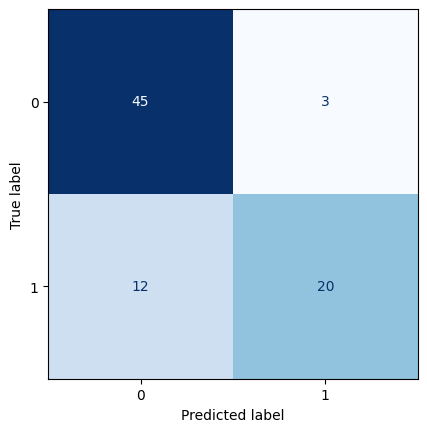

In [36]:
graphe_matrix = ConfusionMatrixDisplay(cm,display_labels=classifieur.classes_)
graphe_matrix.plot(cmap='Blues',colorbar=False)

In [37]:
from sklearn.metrics import accuracy_score

In [42]:
y_test_predicted = classifieur.predict(X_test)

In [40]:
acc_score = accuracy_score(y_test,classifieur.predict(X_test))

In [41]:
acc_score

0.8125

### Modèle de régression logistique et frontière de décision

La régression logistique modélise la probabilité qu’un individu appartienne à la classe 1 (acheter) :

$$
P(y=1 \mid x) = \frac{1}{1 + e^{-(w_0 + w_1 x_1 + w_2 x_2)}}
$$

où :
- $x_1$ : âge  
- $x_2$ : salaire estimé  
- $w_0$ : biais (intercept)  
- $w_1, w_2$ : coefficients du modèle  

---

### Règle de décision

On prédit :
- $y = 1$ si $P(y=1 \mid x) \geq 0.5$
- $y = 0$ sinon  

Le seuil $0.5$ correspond à :

$$
w_0 + w_1 x_1 + w_2 x_2 = 0
$$

---

### Frontière de décision

La frontière de décision est donnée par :

$$
w_0 + w_1 x_1 + w_2 x_2 = 0
$$

On peut la réécrire :

$$
x_2 = -\frac{w_0 + w_1 x_1}{w_2}
$$

---

### Lien avec le code

- `w0 = classifieur.intercept_[0]`
- `w1 = classifieur.coef_[0][0]`
- `w2 = classifieur.coef_[0][1]`

In [45]:
w0 = classifieur.intercept_[0]
w1 = classifieur.coef_[0][0]
w2 = classifieur.coef_[0][1]

In [46]:
import numpy as np

In [48]:
x_values = X_test[:,0]
y_values = [-w1/w2*x-w0/w2 for x in x_values]

Text(0, 0.5, 'Salaire estimé')

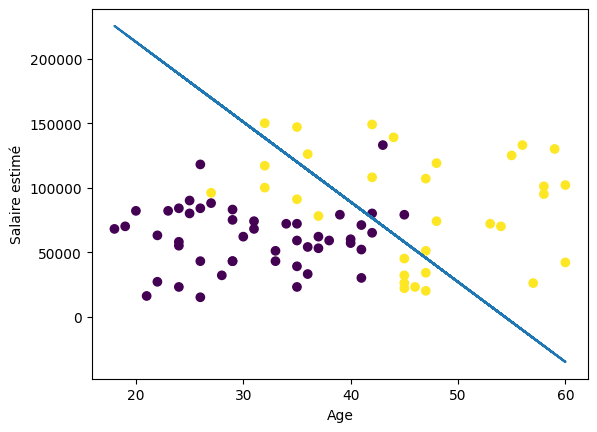

In [50]:
import matplotlib.pyplot as plt
plt.scatter(X_test[:,0],X_test[:,1],c=y_test)
plt.plot(x_values,y_values)
plt.xlabel('Age')
plt.ylabel('Salaire estimé')